In [1]:
# Step 1: Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

pd.set_option("display.max_columns", None)

In [3]:
# Step 2: Load the prepared dataset

df = pd.read_csv("../data/heart_disease_model_ready.csv")

df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,risk_factor_count,total_poor_health_days,Diabetes_1.0,Diabetes_2.0
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,4.0,33.0,0,0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,1.0,0.0,0,0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,3.0,60.0,0,0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,1.0,0.0,0,0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,2.0,3.0,0,0


In [4]:
# Step 3: Check dataset shape

df.shape

(253680, 25)

In [5]:
# Step 4: Check target variable distribution

df["HeartDiseaseorAttack"].value_counts(normalize=True) * 100

HeartDiseaseorAttack
0.0    90.581441
1.0     9.418559
Name: proportion, dtype: float64

In [6]:
# Step 5: Separate features and target variable

X = df.drop("HeartDiseaseorAttack", axis=1)
y = df["HeartDiseaseorAttack"]

In [7]:
# Step 6: Check feature and target shapes

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (253680, 24)
Target shape: (253680,)


In [8]:
# Step 7: Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
# Step 8: Check train and test shapes

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (202944, 24)
X_test shape: (50736, 24)
y_train shape: (202944,)
y_test shape: (50736,)


In [10]:
# Step 10: Check target distribution in testing set

y_test.value_counts(normalize=True) * 100

HeartDiseaseorAttack
0.0    90.580653
1.0     9.419347
Name: proportion, dtype: float64

In [11]:
# Step 11: Scale features for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Step 12: Train Logistic Regression model

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
# Step 13: Make predictions using Logistic Regression

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]

In [14]:
# Step 14: Evaluate Logistic Regression model

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

Logistic Regression Results
Accuracy: 0.753409807631662
Precision: 0.2482089357822066
Recall: 0.797447164678803
F1-score: 0.3785824268613719
ROC-AUC: 0.8470628240816265


In [15]:
# Step 15: Classification report for Logistic Regression

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

         0.0       0.97      0.75      0.85     45957
         1.0       0.25      0.80      0.38      4779

    accuracy                           0.75     50736
   macro avg       0.61      0.77      0.61     50736
weighted avg       0.90      0.75      0.80     50736



In [16]:
# Step 16: Create confusion matrix for Logistic Regression

cm_log = confusion_matrix(y_test, y_pred_log)

cm_log

array([[34414, 11543],
       [  968,  3811]])

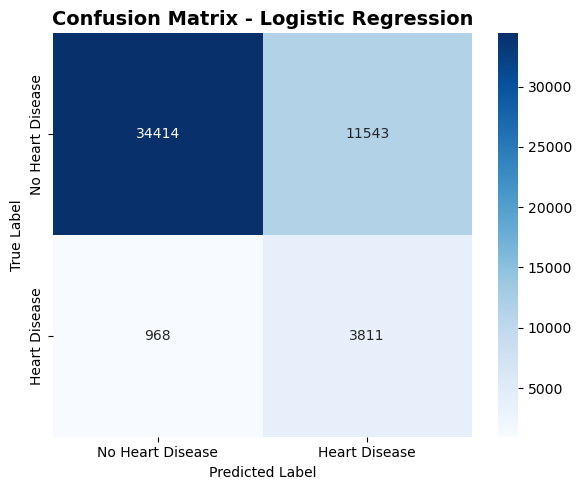

In [17]:
# Step 17: Visualise Logistic Regression confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix - Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Interpretation

The confusion matrix shows how many cases the Logistic Regression model predicted correctly and incorrectly.

For this heart disease risk project, the most important error is false negatives, where the model predicts no heart disease/attack but the actual class is heart disease/attack. This is why recall is an important metric for this project.

In [18]:
# Step 18: Train Random Forest model

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
# Step 19: Make predictions using Random Forest

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [20]:
# Step 20: Evaluate Random Forest model

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Random Forest Results
Accuracy: 0.8992431409649952
Precision: 0.37122969837587005
Recall: 0.10043942247332077
F1-score: 0.15810276679841898
ROC-AUC: 0.8127819092770487


In [21]:
# Step 21: Classification report for Random Forest

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.91      0.98      0.95     45957
         1.0       0.37      0.10      0.16      4779

    accuracy                           0.90     50736
   macro avg       0.64      0.54      0.55     50736
weighted avg       0.86      0.90      0.87     50736



In [22]:
# Step 22: Create confusion matrix for Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_rf

array([[45144,   813],
       [ 4299,   480]])

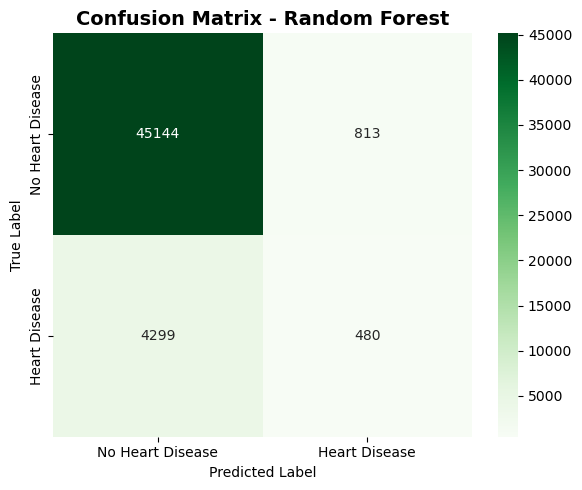

In [23]:
# Step 23: Visualise Random Forest confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix - Random Forest", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Interpretation

The Random Forest model was trained to capture non-linear relationships between the health indicators and heart disease/heart attack status. The confusion matrix shows how many cases were correctly and incorrectly classified. As this is a health-risk prediction problem, recall for the heart disease class remains especially important.

In [24]:
# Step 24: Train XGBoost model

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [25]:
# Step 25: Make predictions using XGBoost

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [26]:
# Step 26: Evaluate XGBoost model

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1-score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

XGBoost Results
Accuracy: 0.9074227373068433
Precision: 0.5502450980392157
Recall: 0.09395270977191882
F1-score: 0.16050044682752457
ROC-AUC: 0.8501577183722825


In [27]:
# Step 27: Classification report for XGBoost

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95     45957
         1.0       0.55      0.09      0.16      4779

    accuracy                           0.91     50736
   macro avg       0.73      0.54      0.56     50736
weighted avg       0.88      0.91      0.88     50736



In [28]:
# Step 28: Create confusion matrix for XGBoost

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

cm_xgb

array([[45590,   367],
       [ 4330,   449]])

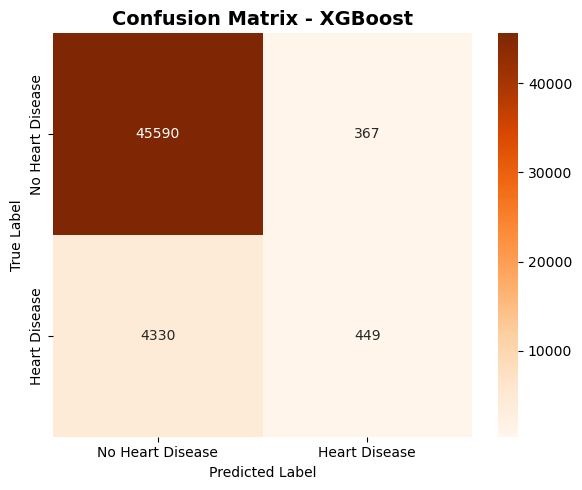

In [29]:
# Step 29: Visualise XGBoost confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Heart Disease", "Heart Disease"],
    yticklabels=["No Heart Disease", "Heart Disease"]
)

plt.title("Confusion Matrix - XGBoost", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

### Interpretation

The XGBoost model was trained as a high-performance boosting model for the heart disease prediction task. The confusion matrix shows how well the model separates heart disease/attack and no heart disease/attack cases. For this project, recall for the heart disease class is especially important because false negatives mean actual heart disease/attack cases were missed.

In [30]:
# Step 30: Create model comparison table

model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.753410,0.248209,0.797447,0.378582,0.847063
1,Random Forest,0.899243,0.371230,0.100439,0.158103,0.812782
2,XGBoost,0.907423,0.550245,0.093953,0.160500,0.850158


In [31]:
# Step 31: Round model comparison results

model_results_rounded = model_results.copy()

numeric_columns = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
model_results_rounded[numeric_columns] = model_results_rounded[numeric_columns].round(4)

model_results_rounded

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7534,0.2482,0.7974,0.3786,0.8471
1,Random Forest,0.8992,0.3712,0.1004,0.1581,0.8128
2,XGBoost,0.9074,0.5502,0.0940,0.1605,0.8502


In [32]:
# Step 32: Sort models by recall

model_results_rounded.sort_values(by="Recall", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7534,0.2482,0.7974,0.3786,0.8471
1,Random Forest,0.8992,0.3712,0.1004,0.1581,0.8128
2,XGBoost,0.9074,0.5502,0.0940,0.1605,0.8502


In [33]:
# Step 33: Sort models by ROC-AUC

model_results_rounded.sort_values(by="ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
2,XGBoost,0.9074,0.5502,0.0940,0.1605,0.8502
0,Logistic Regression,0.7534,0.2482,0.7974,0.3786,0.8471
1,Random Forest,0.8992,0.3712,0.1004,0.1581,0.8128


In [34]:
# Step 34: Select best model based on recall and ROC-AUC

best_model_name = "Logistic Regression"
best_model = log_reg

print("Best model selected:", best_model_name)

Best model selected: Logistic Regression


### Interpretation

Although Random Forest and XGBoost achieved higher accuracy, their recall scores were very low. This means they missed many actual heart disease/heart attack cases.

For this project, recall is more important than accuracy because the goal is to identify people who may be at risk. Logistic Regression was selected as the best model at this stage because it achieved the highest recall while maintaining a strong ROC-AUC score.

In [35]:
# Step 35: Create models folder if it does not exist

import os

os.makedirs("../models", exist_ok=True)

In [36]:
# Step 36: Save the best model and scaler

joblib.dump(best_model, "../models/logistic_regression_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [37]:
# Step 37: Confirm saved model files

os.listdir("../models")

['shap_feature_importance.csv',
 'scaler.pkl',
 'logistic_regression_model.pkl',
 'logistic_regression_feature_importance.csv',
 'app_feature_value_guide.csv',
 'model_comparison_results.csv',
 'logistic_regression_predictions.csv',
 'final_model_summary.csv',
 'app_preparation_summary.csv',
 'shap_sample_data.csv',
 'shap_explanation_summary.csv']

### Interpretation

The Logistic Regression model and scaler were saved so they can be reused later in the final Gradio app. The scaler is important because the Logistic Regression model was trained using scaled features.

/opt/anaconda3/envs/heart-capstone/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


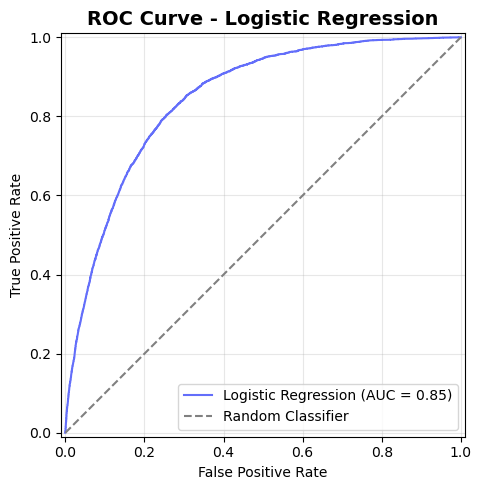

/opt/anaconda3/envs/heart-capstone/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


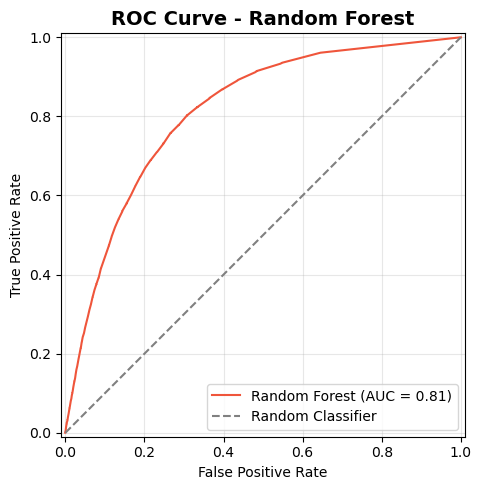

/opt/anaconda3/envs/heart-capstone/lib/python3.10/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


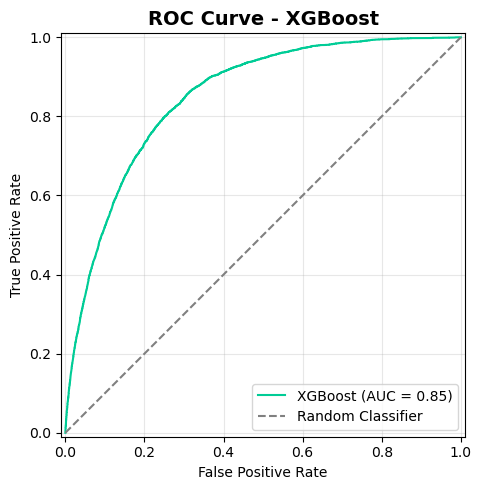

In [38]:
# Step 38A: Static ROC curves for each model separately

roc_models = [
    ("Logistic Regression", y_prob_log, "#636EFA"),
    ("Random Forest", y_prob_rf, "#EF553B"),
    ("XGBoost", y_prob_xgb, "#00CC96")
]

for model_name, y_prob, color in roc_models:
    fig, ax = plt.subplots(figsize=(7, 5))

    RocCurveDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name,
        color=color,
        ax=ax
    )

    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        color="gray",
        label="Random Classifier"
    )

    plt.title(f"ROC Curve - {model_name}", fontsize=14, fontweight="bold")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

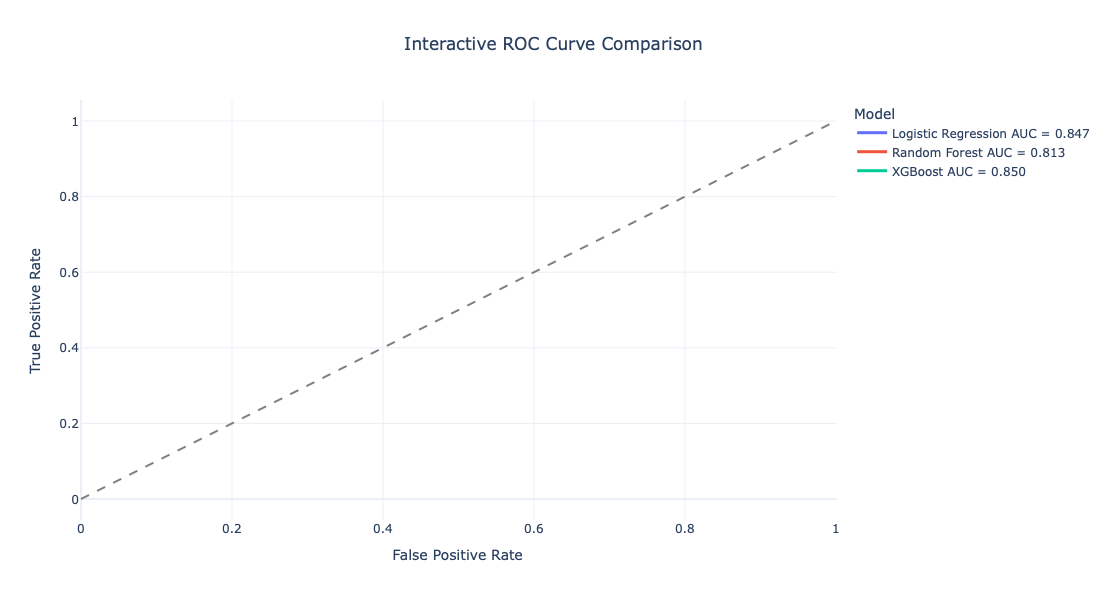

In [39]:
# Step 38: Interactive ROC curve comparison for all models

from sklearn.metrics import roc_curve, auc

# Calculate ROC curve values
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Calculate AUC values
auc_log = auc(fpr_log, tpr_log)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

# Create dataframe for Plotly
roc_df = pd.DataFrame({
    "False Positive Rate": list(fpr_log) + list(fpr_rf) + list(fpr_xgb),
    "True Positive Rate": list(tpr_log) + list(tpr_rf) + list(tpr_xgb),
    "Model": (
        [f"Logistic Regression AUC = {auc_log:.3f}"] * len(fpr_log) +
        [f"Random Forest AUC = {auc_rf:.3f}"] * len(fpr_rf) +
        [f"XGBoost AUC = {auc_xgb:.3f}"] * len(fpr_xgb)
    )
})

fig = px.line(
    roc_df,
    x="False Positive Rate",
    y="True Positive Rate",
    color="Model",
    title="Interactive ROC Curve Comparison"
)

# Add diagonal baseline line
fig.add_shape(
    type="line",
    x0=0,
    y0=0,
    x1=1,
    y1=1,
    line=dict(dash="dash", color="gray")
)

fig.update_traces(
    line=dict(width=3),
    hovertemplate="<b>%{fullData.name}</b><br>False Positive Rate: %{x:.3f}<br>True Positive Rate: %{y:.3f}<extra></extra>"
)

fig.update_layout(
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    title_x=0.5,
    template="plotly_white",
    width=900,
    height=600
)

fig

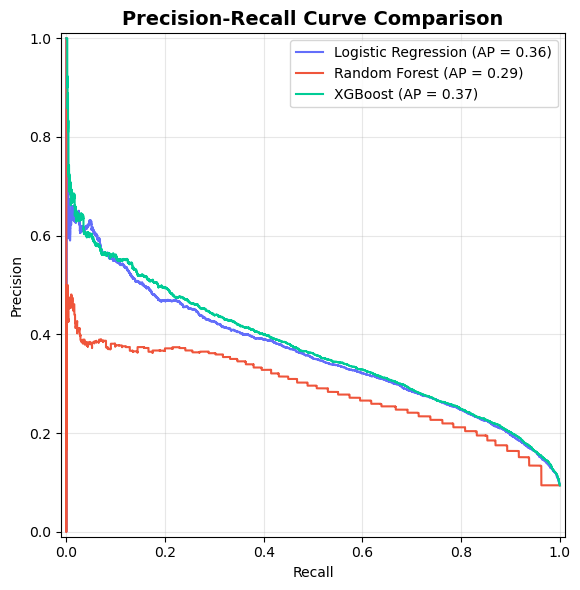

In [43]:
# Step 39: Plot Precision-Recall curves for all models

from sklearn.metrics import PrecisionRecallDisplay

pr_models = [
    ("Logistic Regression", y_prob_log, "#636EFA"),
    ("Random Forest", y_prob_rf, "#EF553B"),
    ("XGBoost", y_prob_xgb, "#00CC96")
]

fig, ax = plt.subplots(figsize=(8, 6))

for model_name, y_prob, color in pr_models:
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_prob,
        name=model_name,
        color=color,
        ax=ax
    )

plt.title("Precision-Recall Curve Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Step 40: Save model comparison results

model_results_rounded.to_csv("../models/model_comparison_results.csv", index=False)

In [45]:
# Step 41: Confirm saved files in models folder

os.listdir("../models")

['scaler.pkl', 'logistic_regression_model.pkl', 'model_comparison_results.csv']

In [46]:
# Step 42: Load saved model comparison results

saved_results = pd.read_csv("../models/model_comparison_results.csv")

saved_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.7534,0.2482,0.7970,0.3785,0.8470
1,Random Forest,0.8996,0.3761,0.0994,0.1572,0.8127
2,XGBoost,0.9078,0.5605,0.0998,0.1694,0.8508


### Interpretation

The model comparison results were saved so they can be used later in the capstone report, presentation slides, and final dashboard/app. The comparison shows that Logistic Regression is the most suitable model at this stage because it has the strongest recall for identifying heart disease/heart attack cases.

In [47]:
# Step 43: Save final predictions for analysis

prediction_results = X_test.copy()
prediction_results["Actual"] = y_test.values
prediction_results["Predicted_Logistic_Regression"] = y_pred_log
prediction_results["Predicted_Probability_Logistic_Regression"] = y_prob_log

prediction_results.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Actual,Predicted_Logistic_Regression,Predicted_Probability_Logistic_Regression
198911,1.0,1.0,1.0,30.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,11.0,6.0,8.0,0.0,1.0,0.863522
30665,1.0,1.0,1.0,27.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.0,4.0,0.0,0.0,0.0,11.0,6.0,6.0,0.0,0.0,0.409644
74347,1.0,0.0,1.0,31.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,3.0,3.0,0.0,0.0,6.0,6.0,7.0,0.0,0.0,0.125477
49710,0.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,12.0,6.0,6.0,0.0,1.0,0.551577
46572,1.0,1.0,1.0,25.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,9.0,5.0,7.0,0.0,0.0,0.429396


In [48]:
# Step 44: Save prediction results

prediction_results.to_csv("../models/logistic_regression_predictions.csv", index=False)

In [49]:
# Step 45: Confirm prediction results file

os.listdir("../models")

['scaler.pkl',
 'logistic_regression_model.pkl',
 'model_comparison_results.csv',
 'logistic_regression_predictions.csv']

In [50]:
# Step 46: Create final model summary

final_model_summary = {
    "Selected Model": best_model_name,
    "Reason for Selection": "Highest recall for heart disease/heart attack class with strong ROC-AUC",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1-score": f1_score(y_test, y_pred_log),
    "ROC-AUC": roc_auc_score(y_test, y_prob_log)
}

final_model_summary

{'Selected Model': 'Logistic Regression',
 'Reason for Selection': 'Highest recall for heart disease/heart attack class with strong ROC-AUC',
 'Accuracy': 0.7534295175023652,
 'Precision': 0.2481594892175386,
 'Recall': 0.7970286670851643,
 'F1-score': 0.37847774244833066,
 'ROC-AUC': 0.847031152418318}

In [51]:
# Step 47: Convert final model summary to DataFrame

final_model_summary_df = pd.DataFrame([final_model_summary])

final_model_summary_df

,Selected Model,Reason for Selection,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,Highest recall for heart disease/heart attack ...,0.75343,0.248159,0.797029,0.378478,0.847031


In [52]:
# Step 48: Save final model summary

final_model_summary_df.to_csv("../models/final_model_summary.csv", index=False)

In [53]:
# Step 49: Confirm all saved files

os.listdir("../models")

['scaler.pkl',
 'logistic_regression_model.pkl',
 'model_comparison_results.csv',
 'logistic_regression_predictions.csv',
 'final_model_summary.csv']

### Final Model Summary

Logistic Regression was selected as the final model at this stage because it achieved the highest recall for the heart disease/heart attack class. In this project, recall is especially important because false negatives represent actual heart disease/heart attack cases that the model failed to identify.

The saved model, scaler, prediction results and model comparison files will be used later for the Gradio app, dashboard and capstone presentation.

In [54]:
# Step 50: Extract Logistic Regression feature coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
})

feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
18,Age,0.846608,0.846608
13,GenHlth,0.527404,0.527404
17,Sex,0.408648,0.408648
1,HighChol,0.315863,0.315863
0,HighBP,0.276679,0.276679
5,Stroke,0.222490,0.222490
4,Smoker,0.190853,0.190853
16,DiffWalk,0.119921,0.119921
20,Income,-0.114768,0.114768
6,Diabetes,0.108077,0.108077


In [55]:
# Step 51: Display top 15 important features

top_features = feature_importance.head(15)

top_features

,Feature,Coefficient,Absolute Coefficient
18,Age,0.846608,0.846608
13,GenHlth,0.527404,0.527404
17,Sex,0.408648,0.408648
1,HighChol,0.315863,0.315863
0,HighBP,0.276679,0.276679
5,Stroke,0.222490,0.222490
4,Smoker,0.190853,0.190853
16,DiffWalk,0.119921,0.119921
20,Income,-0.114768,0.114768
6,Diabetes,0.108077,0.108077


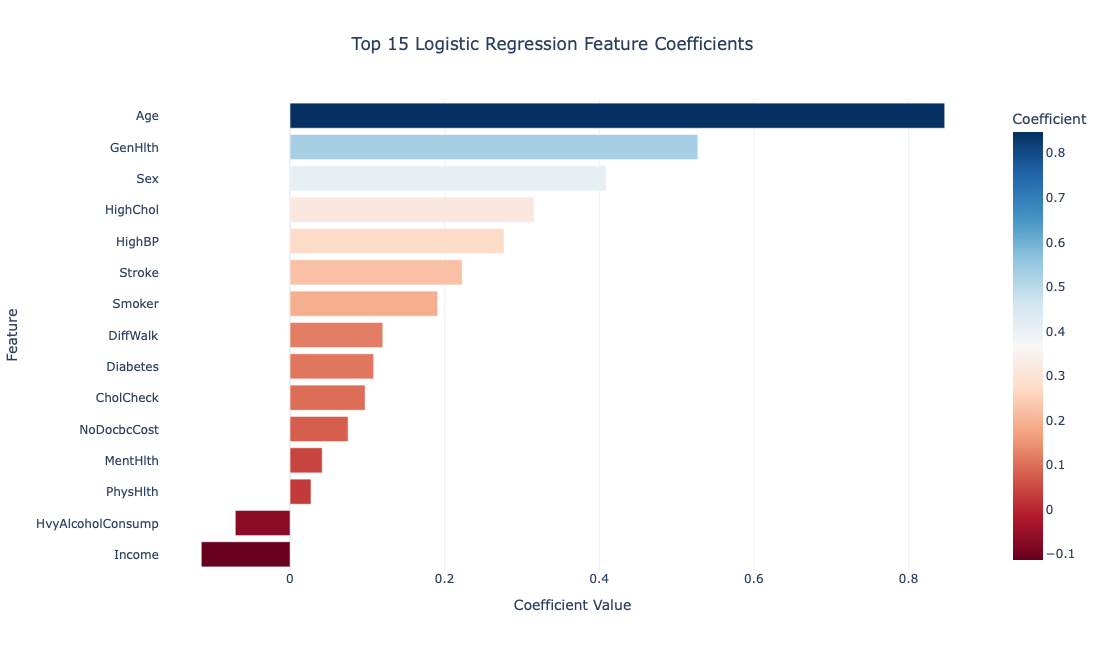

In [56]:
# Step 52: Visualise top 15 Logistic Regression feature coefficients

fig = px.bar(
    top_features.sort_values(by="Coefficient"),
    x="Coefficient",
    y="Feature",
    orientation="h",
    title="Top 15 Logistic Regression Feature Coefficients",
    color="Coefficient",
    color_continuous_scale="RdBu"
)

fig.update_layout(
    xaxis_title="Coefficient Value",
    yaxis_title="Feature",
    title_x=0.5,
    template="plotly_white",
    width=900,
    height=650
)

fig

### Interpretation

The Logistic Regression coefficients show which features contribute most strongly to the model prediction. Positive coefficients increase the predicted probability of heart disease/heart attack, while negative coefficients reduce the predicted probability.

These results provide an initial explanation of the model, but SHAP explainability will be used in the next notebook for a more detailed and reliable feature-level interpretation.